# Analysis of NTK Eigenvalue and Eigenvector Distributions

We analyze the distributions of eigenvalues and eigenvectors of the NTK matrix.

In [ ]:
import os
import numpy as np
import jax.numpy as jnp

import matplotlib.pyplot as plt
from tqdm import tqdm
import csv  # we use csv instead of pandas
from collections import defaultdict  # we use defaultdict for grouping
import json  # we add json for storing test results
import seaborn as sns  # we use seaborn for enhanced heatmap visualizations

In [ ]:
import dotenv
dotenv.load_dotenv()
PROJECT_ROOT = os.getenv("PROJECT_ROOT")
PATH_TO_DATA = os.path.join(PROJECT_ROOT, "experiments", "data", "eigen")
PATH_TO_PLOTS = os.path.join(PROJECT_ROOT, "experiments", "plots", "eigen", "other_vectors")
PATH_TO_SAVE_GRAM_MATRIX = os.path.join(PROJECT_ROOT, "experiments", "data", "eigen", "gram")
# we create necessary directories
os.makedirs(PATH_TO_PLOTS, exist_ok=True)

In [ ]:
def get_config_from_filename(filename):
    """we extract configuration parameters from filename"""
    parts = filename.replace(".npy", "").split("_")
    N = int(parts[-4][1:])
    D = int(parts[-3][1:])
    M = int(parts[-2][1:])
    L = int(parts[-1][1:])
    return N, D, M, L

def load_experiment_data(N, D_IN, M, L):
    """we load eigenvalues and eigenvectors data for a specific configuration"""
    filename_eigenvalues = f"values/ntk_eigenvalues_N{N}_D{D_IN}_M{M}_L{L}.npy"
    filename_eigenvectors = f"vectors/ntk_eigenvectors_N{N}_D{D_IN}_M{M}_L{L}.npy"
    
    eigenvalues_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvalues), allow_pickle=True).item()
    eigenvectors_data = np.load(os.path.join(PATH_TO_DATA, filename_eigenvectors), allow_pickle=True).item()
    
    return eigenvalues_data, eigenvectors_data

In [ ]:

def get_ordinal_suffix(n):
    """we get the ordinal suffix for a number (1st, 2nd, 3rd, 4th, etc.)"""
    if 10 <= n % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')
    return f"{n}{suffix}"

def plot_eigenvector_coordinate_distributions(eigenvectors, eigenvector_order, N, D_IN, M, L, output_dir):
    """
    we plot the distribution of each coordinate/component for a specific eigenvector order.
    for each coordinate i, we plot the histogram of values across all experiments.
    """
    # eigenvectors shape: (n_experiments, n_vectors, dimension)
    try:
        selected_eigenvectors = eigenvectors[:, eigenvector_order, :] # we get shape (n_experiments, dimension)
    except IndexError:
        print(f"Warning: Could not extract eigenvector {eigenvector_order+1} for config N{N}_D{D_IN}_M{M}_L{L}. Eigenvector array might be empty or have wrong dimensions.")
        return

    n_experiments, dimension = selected_eigenvectors.shape
    
    # we compute number of rows and columns for subplots
    n_cols = min(4, dimension)  # we limit to 4 columns maximum
    n_rows = (dimension + n_cols - 1) // n_cols  # we compute rows needed
    
    # we create the figure with subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    order_str = get_ordinal_suffix(eigenvector_order + 1)
    fig.suptitle(f'Distribution of Each Coordinate - {order_str} Eigenvector\nConfig N{N}_D{D_IN}_M{M}_L{L}', fontsize=16)
    
    # we flatten axes array for easier indexing
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    # we plot distribution for each coordinate
    for i in range(dimension):
        coordinate_values = selected_eigenvectors[:, i]  # we get values for coordinate i across all experiments
        
        ax = axes[i] if i < len(axes) else None
        if ax is None:
            continue
            
        # we plot histogram
        ax.hist(coordinate_values, bins='auto', density=True, alpha=0.7, color=f'C{i%10}')
        
        # we add statistics
        mean_val = np.mean(coordinate_values)
        std_val = np.std(coordinate_values)
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.8)
        
        ax.set_title(f'Coordinate {i+1}\nMean: {mean_val:.4f}, Std: {std_val:.4f}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        
        # we add text box with additional statistics
        stats_text = f'Min: {np.min(coordinate_values):.4f}\nMax: {np.max(coordinate_values):.4f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=8,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    
    # we hide unused subplots
    for i in range(dimension, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    # we save the plot
    plot_filename = os.path.join(output_dir, f'{order_str}_eigenvector_coordinates_dist_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(plot_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # we also create a summary statistics plot
    plt.figure(figsize=(12, 8))
    
    # we compute statistics for all coordinates
    coordinate_means = [np.mean(selected_eigenvectors[:, i]) for i in range(dimension)]
    coordinate_stds = [np.std(selected_eigenvectors[:, i]) for i in range(dimension)]
    coordinate_mins = [np.min(selected_eigenvectors[:, i]) for i in range(dimension)]
    coordinate_maxs = [np.max(selected_eigenvectors[:, i]) for i in range(dimension)]
    
    coordinate_indices = list(range(1, dimension + 1))  # we start from 1
    
    plt.subplot(2, 2, 1)
    plt.plot(coordinate_indices, coordinate_means, 'o-', linewidth=2, markersize=6)
    plt.title(f'Mean Value per Coordinate - {order_str} Eigenvector\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Coordinate Index')
    plt.ylabel('Mean Value')
    plt.grid(True)
    
    plt.subplot(2, 2, 2)
    plt.plot(coordinate_indices, coordinate_stds, 'o-', color='orange', linewidth=2, markersize=6)
    plt.title(f'Standard Deviation per Coordinate - {order_str} Eigenvector\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Coordinate Index')
    plt.ylabel('Standard Deviation')
    plt.grid(True)
    
    plt.subplot(2, 2, 3)
    plt.plot(coordinate_indices, coordinate_mins, 'o-', color='green', linewidth=2, markersize=6, label='Min')
    plt.plot(coordinate_indices, coordinate_maxs, 's-', color='red', linewidth=2, markersize=6, label='Max')
    plt.title(f'Min/Max Values per Coordinate - {order_str} Eigenvector\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Coordinate Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(2, 2, 4)
    coordinate_ranges = [coordinate_maxs[i] - coordinate_mins[i] for i in range(dimension)]
    plt.plot(coordinate_indices, coordinate_ranges, 'o-', color='purple', linewidth=2, markersize=6)
    plt.title(f'Range (Max-Min) per Coordinate - {order_str} Eigenvector\nConfig N{N}_D{D_IN}_M{M}_L{L}')
    plt.xlabel('Coordinate Index')
    plt.ylabel('Range')
    plt.grid(True)
    
    plt.tight_layout()
    
    # we save the summary plot
    summary_filename = os.path.join(output_dir, f'{order_str}_eigenvector_coordinates_summary_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(summary_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"Coordinate analysis completed for {order_str} eigenvector - N{N}_D{D_IN}_M{M}_L{L}")
    print(f"  Dimension: {dimension}")
    print(f"  Overall mean of means: {np.mean(coordinate_means):.6f}")
    print(f"  Overall std of means: {np.std(coordinate_means):.6f}")
    print(f"  Average std across coordinates: {np.mean(coordinate_stds):.6f}")

def analyze_all_eigenvectors_coordinates(eigenvectors, N, D_IN, M, L, output_dir):
    """
    we analyze the coordinate distributions for all eigenvectors.
    this creates separate plots for each eigenvector order.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    print(f"Analyzing coordinate distributions for all {n_vectors} eigenvectors...")
    print(f"Configuration: N{N}_D{D_IN}_M{M}_L{L}")
    print("=" * 60)
    
    # we analyze each eigenvector order
    for k in tqdm(range(n_vectors), desc=f"Processing eigenvectors for N{N}_D{D_IN}_M{M}_L{L}"):
        plot_eigenvector_coordinate_distributions(eigenvectors, k, N, D_IN, M, L, output_dir)
    
    print(f"Completed coordinate analysis for all {n_vectors} eigenvectors - N{N}_D{D_IN}_M{M}_L{L}")
    print("=" * 60)



def compute_and_plot_gram_matrix(eigenvectors, N, D_IN, M, L, output_dir):
    """
    we compute and visualize the Gram matrix of eigenvectors.
    the Gram matrix G_ij = <v_i, v_j> shows the inner products between eigenvectors.
    """
    n_experiments, n_vectors, dimension = eigenvectors.shape
    
    print(f"Computing Gram matrix for all eigenvectors - N{N}_D{D_IN}_M{M}_L{L}")
    
    # we compute the average Gram matrix across all experiments
    gram_matrices = []
    
    for exp in range(n_experiments):
        # we get eigenvectors for this experiment: shape (n_vectors, dimension)
        exp_eigenvectors = eigenvectors[exp, :, :]
        
        # we compute Gram matrix: G_ij = <v_i, v_j>
        gram_matrix = np.dot(exp_eigenvectors, exp_eigenvectors.T)
        gram_matrices.append(gram_matrix)
    
    # we compute mean and std Gram matrices across experiments
    gram_matrices = np.array(gram_matrices)  # shape: (n_experiments, n_vectors, n_vectors)
    mean_gram_matrix = np.mean(gram_matrices, axis=0)
    std_gram_matrix = np.std(gram_matrices, axis=0)
    
    # we create visualization with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Gram Matrix Analysis - Eigenvectors\nConfig N{N}_D{D_IN}_M{M}_L{L}', fontsize=16)
    
    # we plot mean Gram matrix
    ax1 = axes[0, 0]
    im1 = ax1.imshow(mean_gram_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax1.set_title('Mean Gram Matrix\n<v_i, v_j> averaged over experiments')
    ax1.set_xlabel('Eigenvector j')
    ax1.set_ylabel('Eigenvector i')
    
    # we add colorbar
    cbar1 = plt.colorbar(im1, ax=ax1)
    cbar1.set_label('Inner Product')
    
    # we add text annotations for small matrices
    if n_vectors <= 10:
        for i in range(n_vectors):
            for j in range(n_vectors):
                text = ax1.text(j, i, f'{mean_gram_matrix[i, j]:.3f}',
                               ha="center", va="center", color="black" if abs(mean_gram_matrix[i, j]) < 0.5 else "white",
                               fontsize=8)
    
    # we plot standard deviation of Gram matrix
    ax2 = axes[0, 1]
    im2 = ax2.imshow(std_gram_matrix, cmap='Reds', vmin=0)
    ax2.set_title('Std Dev of Gram Matrix\nVariability across experiments')
    ax2.set_xlabel('Eigenvector j')
    ax2.set_ylabel('Eigenvector i')
    
    cbar2 = plt.colorbar(im2, ax=ax2)
    cbar2.set_label('Standard Deviation')
    
    # we plot diagonal elements (should be ~1 for normalized eigenvectors)
    ax3 = axes[1, 0]
    diagonal_means = np.diag(mean_gram_matrix)
    diagonal_stds = np.diag(std_gram_matrix)
    eigenvector_indices = list(range(1, n_vectors + 1))
    
    ax3.errorbar(eigenvector_indices, diagonal_means, yerr=diagonal_stds, 
                fmt='o-', capsize=5, linewidth=2, markersize=6)
    ax3.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Expected (normalized)')
    ax3.set_title('Diagonal Elements of Gram Matrix\n||v_i||² for each eigenvector')
    ax3.set_xlabel('Eigenvector Index')
    ax3.set_ylabel('||v_i||²')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # we plot off-diagonal statistics (orthogonality)
    ax4 = axes[1, 1]
    
    # we extract off-diagonal elements
    off_diagonal_mask = ~np.eye(n_vectors, dtype=bool)
    off_diagonal_means = mean_gram_matrix[off_diagonal_mask]
    off_diagonal_stds = std_gram_matrix[off_diagonal_mask]
    
    ax4.hist(off_diagonal_means, bins='auto', density=True, alpha=0.7, 
             label=f'Off-diagonal elements\n(n={len(off_diagonal_means)})')
    ax4.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Perfect orthogonality')
    
    # we add statistics
    mean_off_diag = np.mean(off_diagonal_means)
    std_off_diag = np.std(off_diagonal_means)
    ax4.axvline(x=mean_off_diag, color='orange', linestyle='-', alpha=0.8, 
               label=f'Mean: {mean_off_diag:.4f}')
    
    ax4.set_title('Distribution of Off-Diagonal Elements\nOrthogonality check: should be ~0')
    ax4.set_xlabel('Inner Product <v_i, v_j> (i≠j)')
    ax4.set_ylabel('Density')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # we save the plot
    gram_filename = os.path.join(output_dir, f'gram_matrix_analysis_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(gram_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # we create a detailed heatmap using seaborn
    plt.figure(figsize=(12, 10))
    
    # we create labels for better readability
    eigenvector_labels = [f'{get_ordinal_suffix(i+1)}' for i in range(n_vectors)]
    
    # we use seaborn for a more detailed heatmap
    sns.heatmap(mean_gram_matrix, 
                xticklabels=eigenvector_labels,
                yticklabels=eigenvector_labels,
                annot=True if n_vectors <= 12 else False,  # we add annotations for small matrices
                fmt='.3f',
                cmap='RdBu_r',
                center=0,
                vmin=-1, vmax=1,
                square=True,
                cbar_kws={'label': 'Inner Product <v_i, v_j>'})
    
    plt.title(f'Detailed Gram Matrix Heatmap\nConfig N{N}_D{D_IN}_M{M}_L{L}', fontsize=14)
    plt.xlabel('Eigenvector j', fontsize=12)
    plt.ylabel('Eigenvector i', fontsize=12)
    
    # we save the detailed heatmap
    heatmap_filename = os.path.join(output_dir, f'gram_matrix_heatmap_N{N}_D{D_IN}_M{M}_L{L}.png')
    plt.savefig(heatmap_filename, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # we compute and print statistics
    print(f"Gram Matrix Statistics for N{N}_D{D_IN}_M{M}_L{L}:")
    print(f"  Matrix shape: {mean_gram_matrix.shape}")
    print(f"  Diagonal mean: {np.mean(diagonal_means):.6f} ± {np.mean(diagonal_stds):.6f}")
    print(f"  Off-diagonal mean: {mean_off_diag:.6f} ± {std_off_diag:.6f}")
    print(f"  Max off-diagonal: {np.max(np.abs(off_diagonal_means)):.6f}")
    print(f"  Orthogonality score (1 - max|<v_i,v_j>|): {1 - np.max(np.abs(off_diagonal_means)):.6f}")
    
    # we save Gram matrix data as numpy array
    gram_data_filename = os.path.join(PATH_TO_SAVE_GRAM_MATRIX, f'gram_matrix_data_N{N}_D{D_IN}_M{M}_L{L}.npz')
    np.savez(gram_data_filename,
             mean_gram_matrix=mean_gram_matrix,
             std_gram_matrix=std_gram_matrix,
             all_gram_matrices=gram_matrices,
             config={'N': N, 'D_IN': D_IN, 'M': M, 'L': L})
    
    return {
        'mean_gram_matrix': mean_gram_matrix,
        'std_gram_matrix': std_gram_matrix,
        'diagonal_mean': np.mean(diagonal_means),
        'off_diagonal_mean': mean_off_diag,
        'off_diagonal_std': std_off_diag,
        'max_off_diagonal': np.max(np.abs(off_diagonal_means)),
        'orthogonality_score': 1 - np.max(np.abs(off_diagonal_means))
    }




Processing all experiment files for all eigenvectors coordinate analysis...


Processing experiment files:   0%|          | 0/1 [00:00<?, ?it/s]

Analyzing coordinate distributions for all 8 eigenvectors...
Configuration: N8_D20_M10_L8


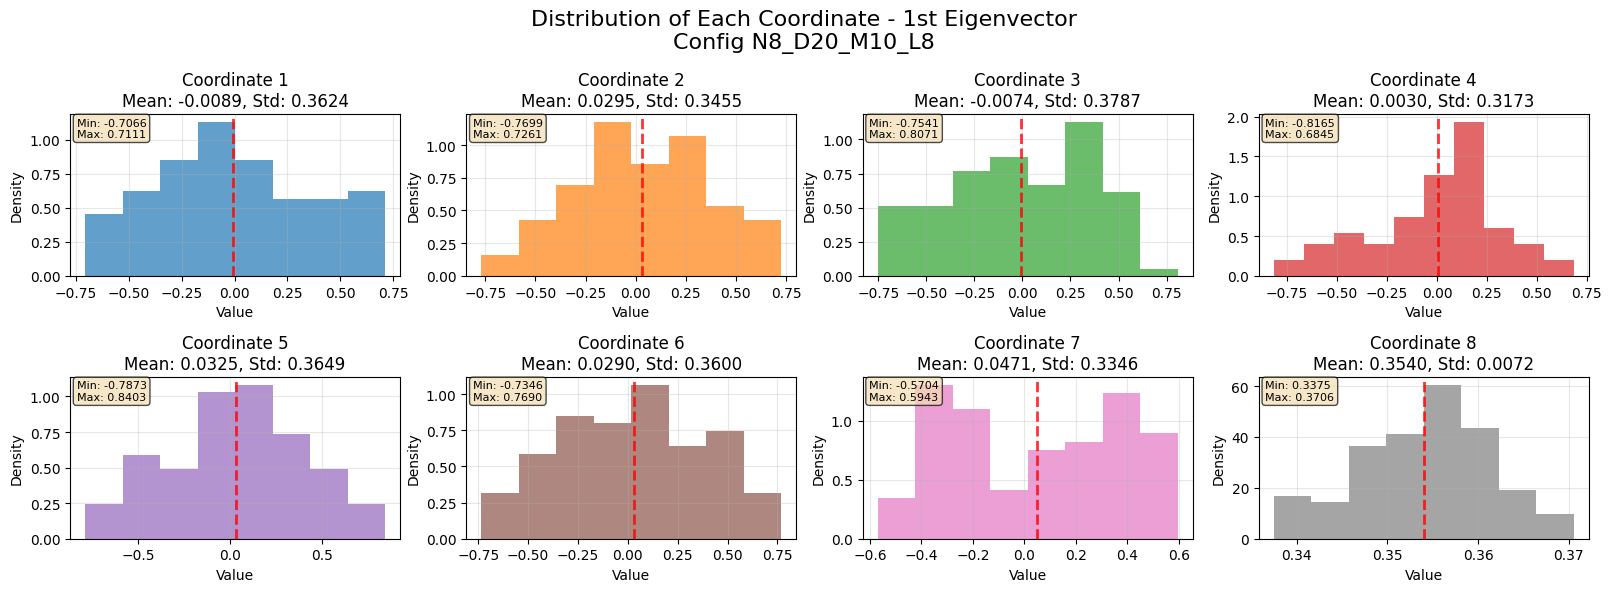

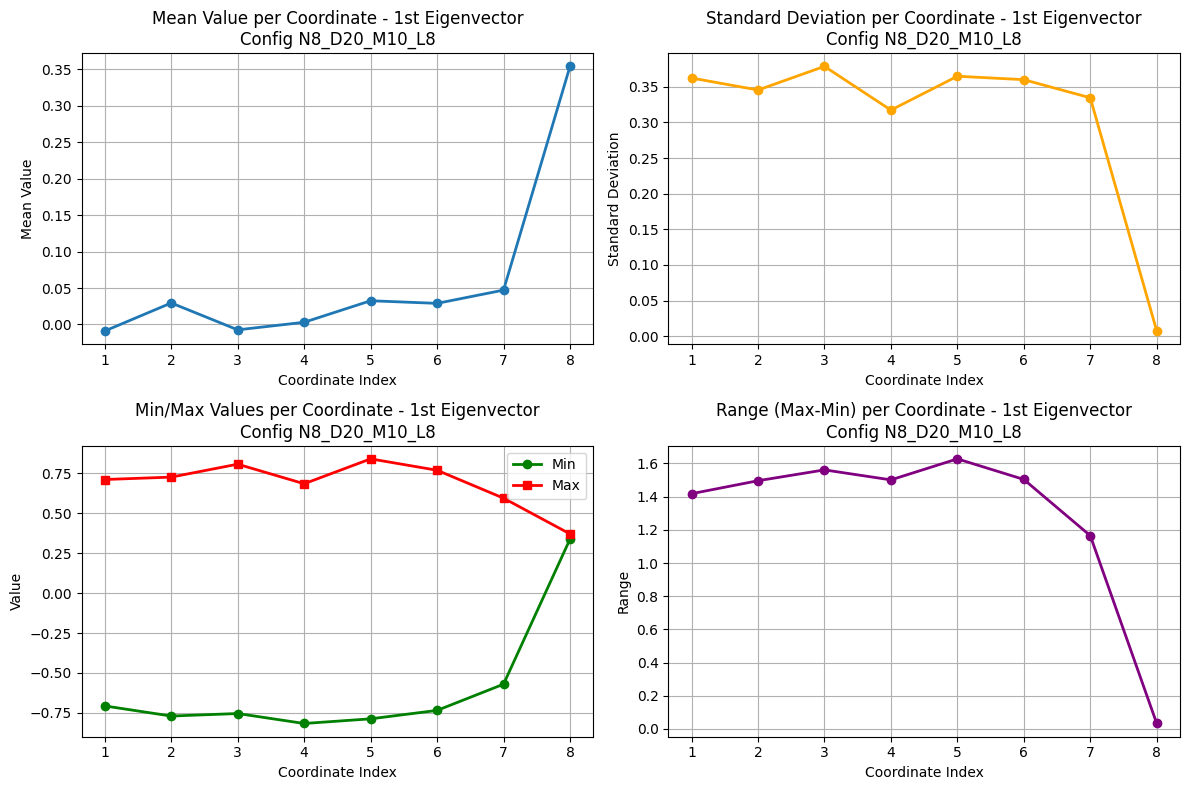

Coordinate analysis completed for 1st eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.059859
  Overall std of means: 0.112797
  Average std across coordinates: 0.308829


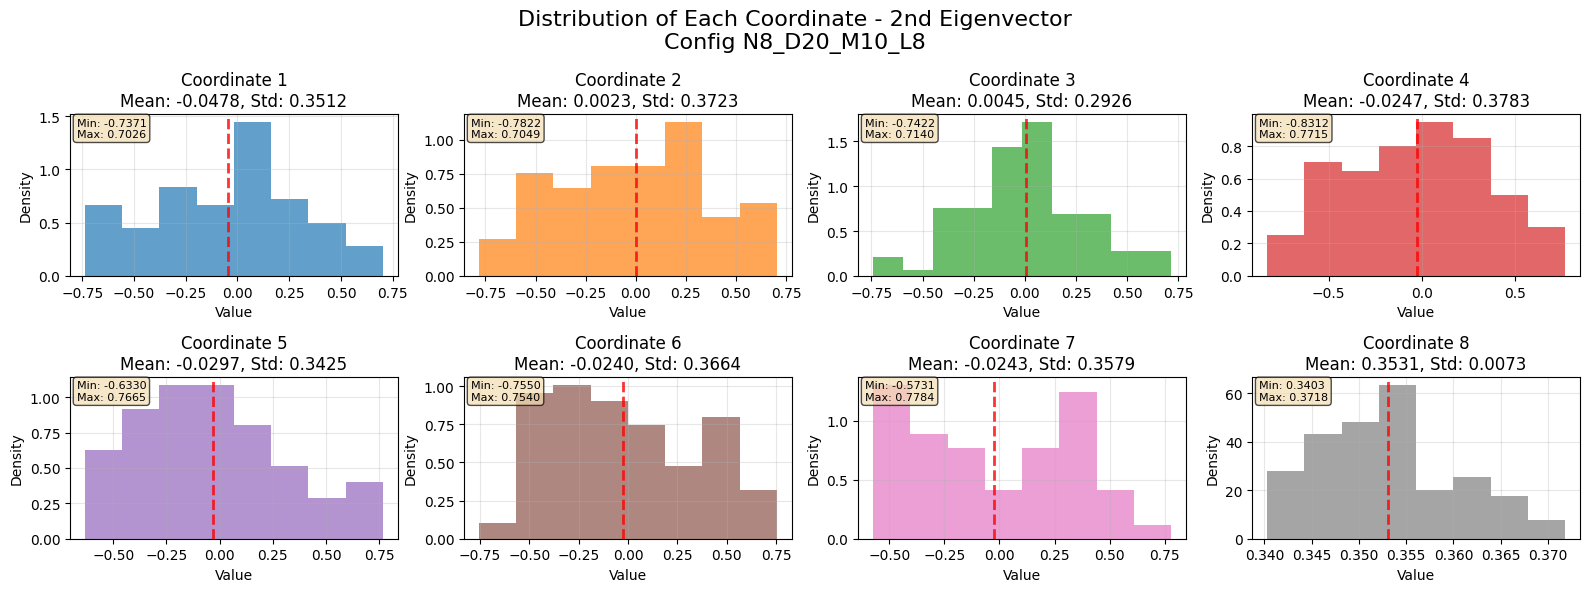

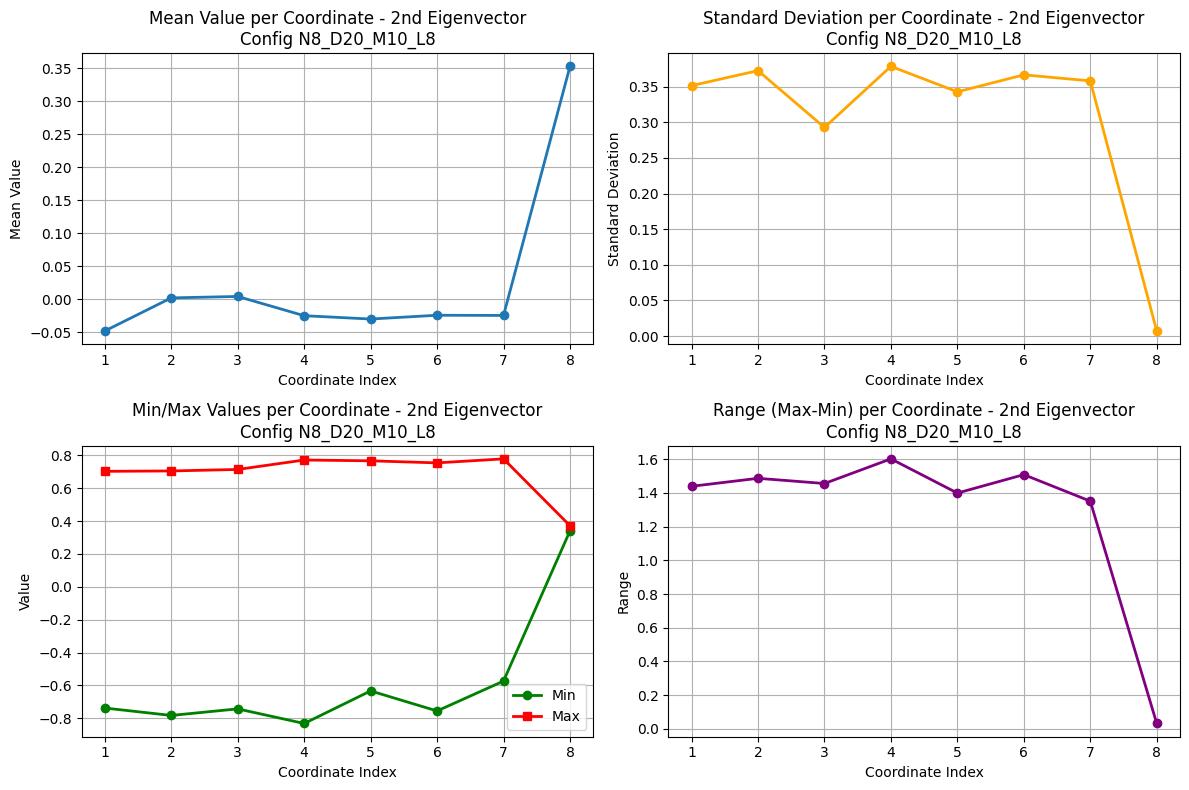

Coordinate analysis completed for 2nd eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.026170
  Overall std of means: 0.124596
  Average std across coordinates: 0.308548


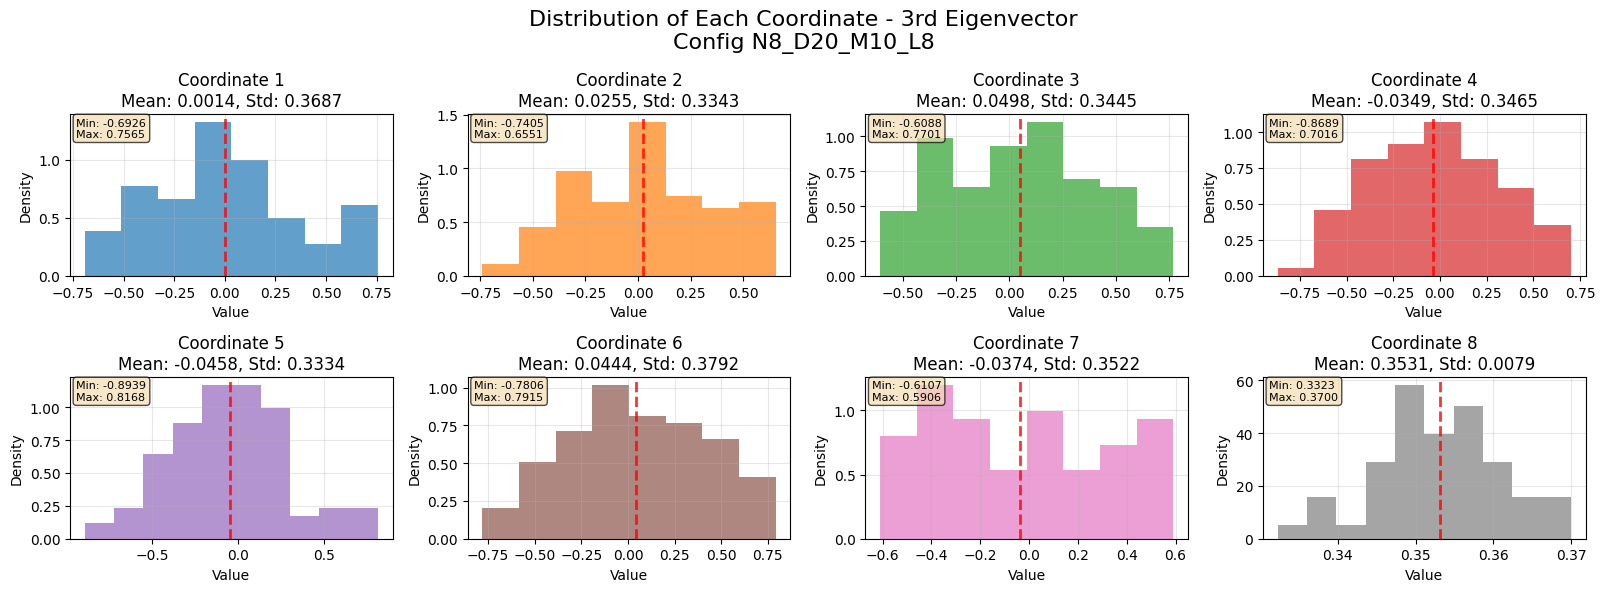

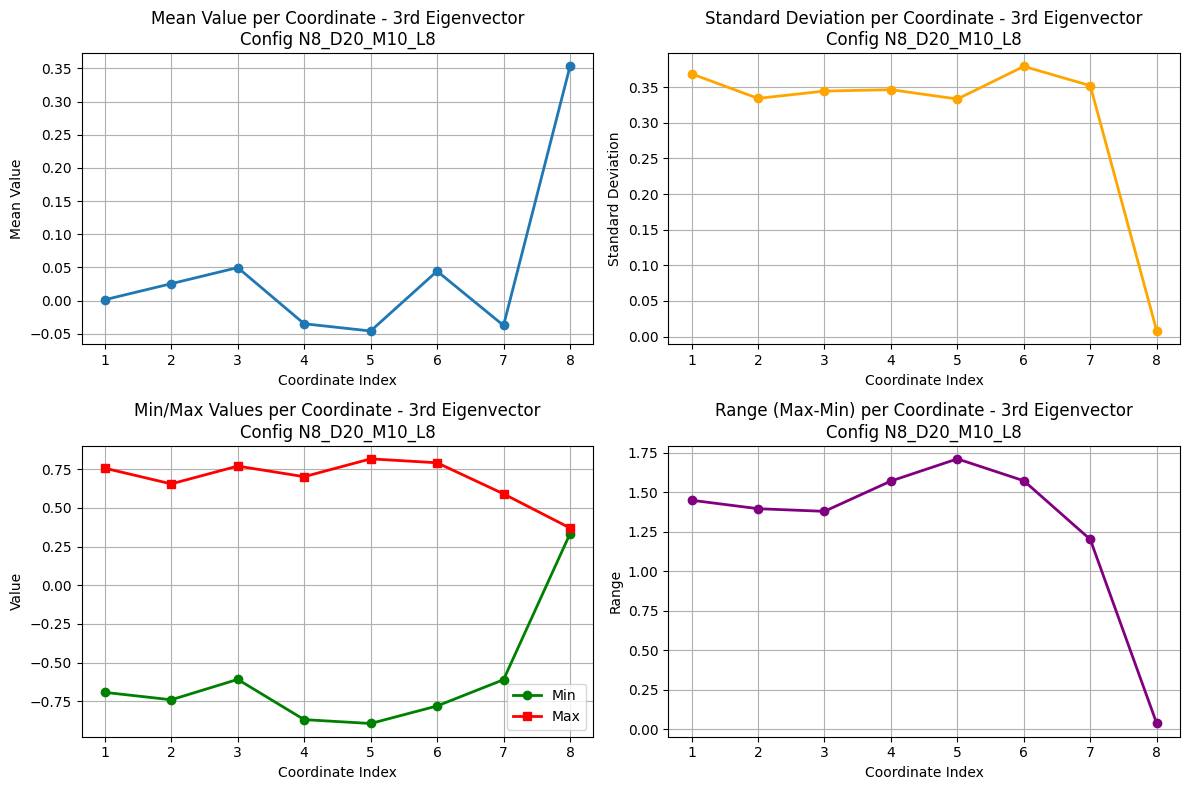

Coordinate analysis completed for 3rd eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.044518
  Overall std of means: 0.121796
  Average std across coordinates: 0.308332


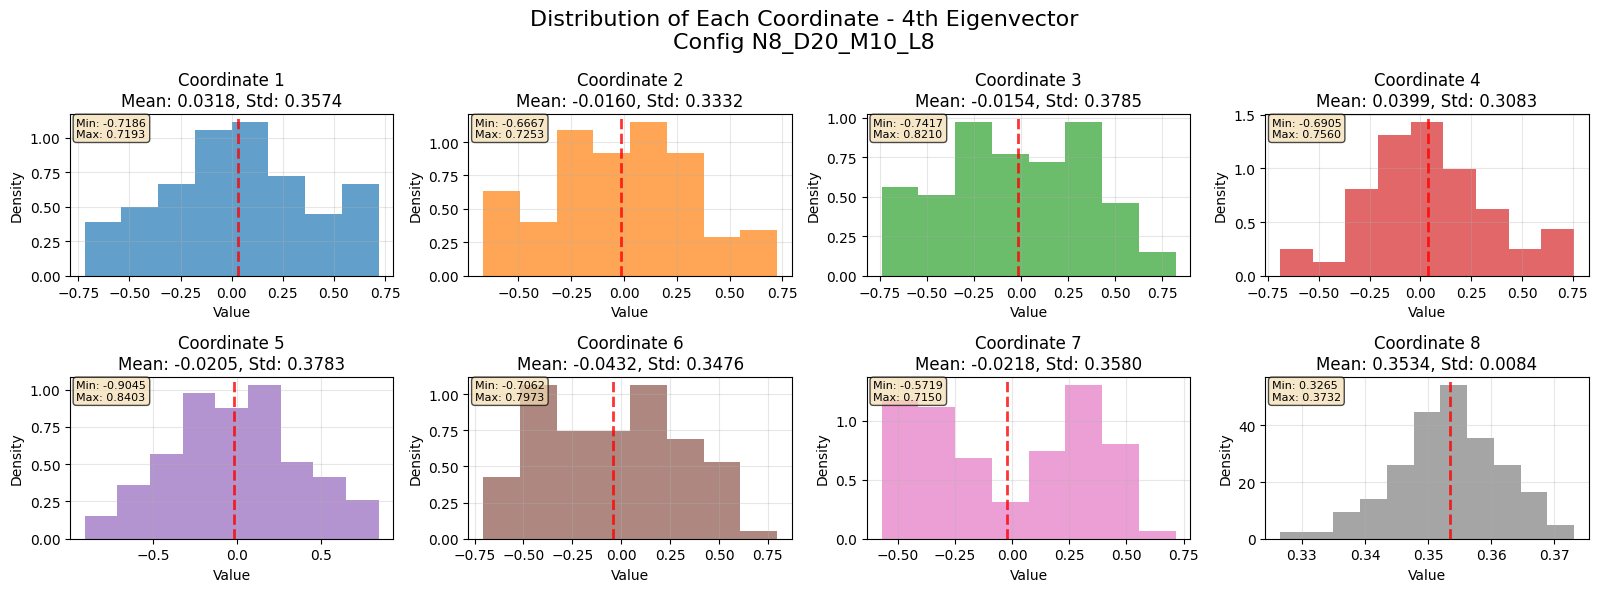

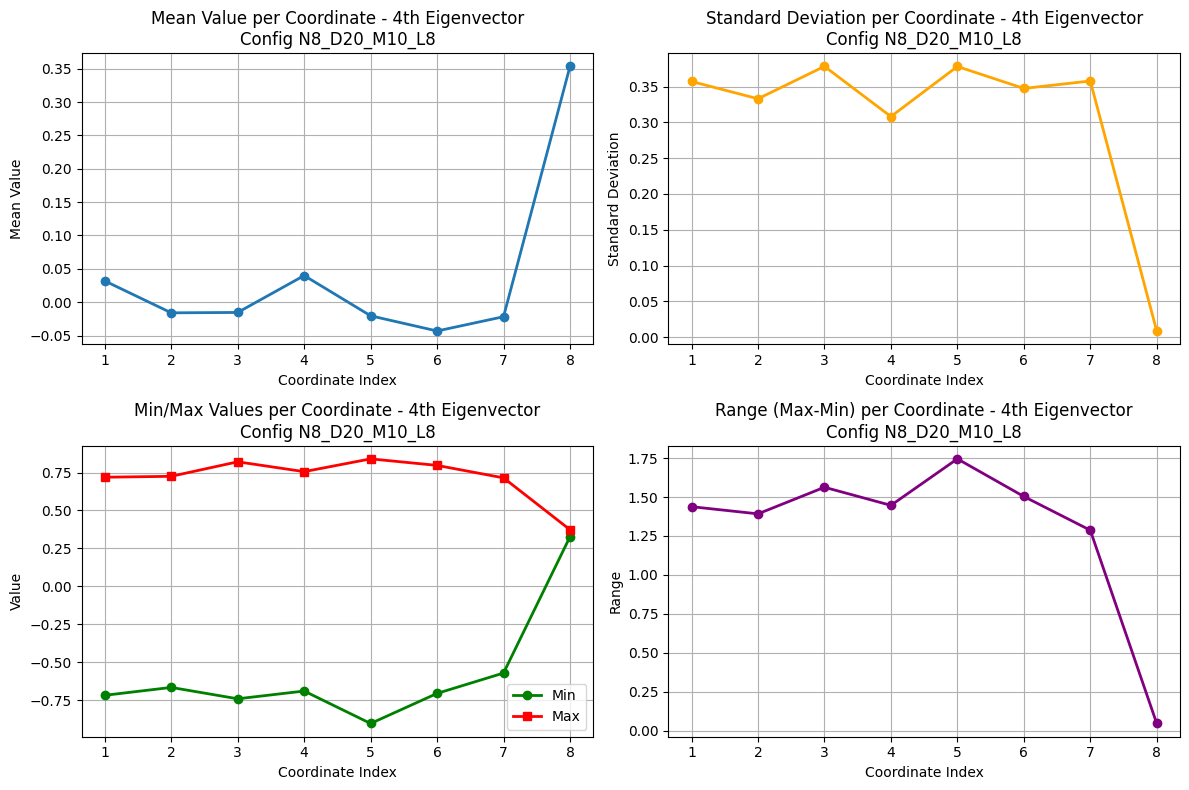

Coordinate analysis completed for 4th eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.038525
  Overall std of means: 0.121917
  Average std across coordinates: 0.308712


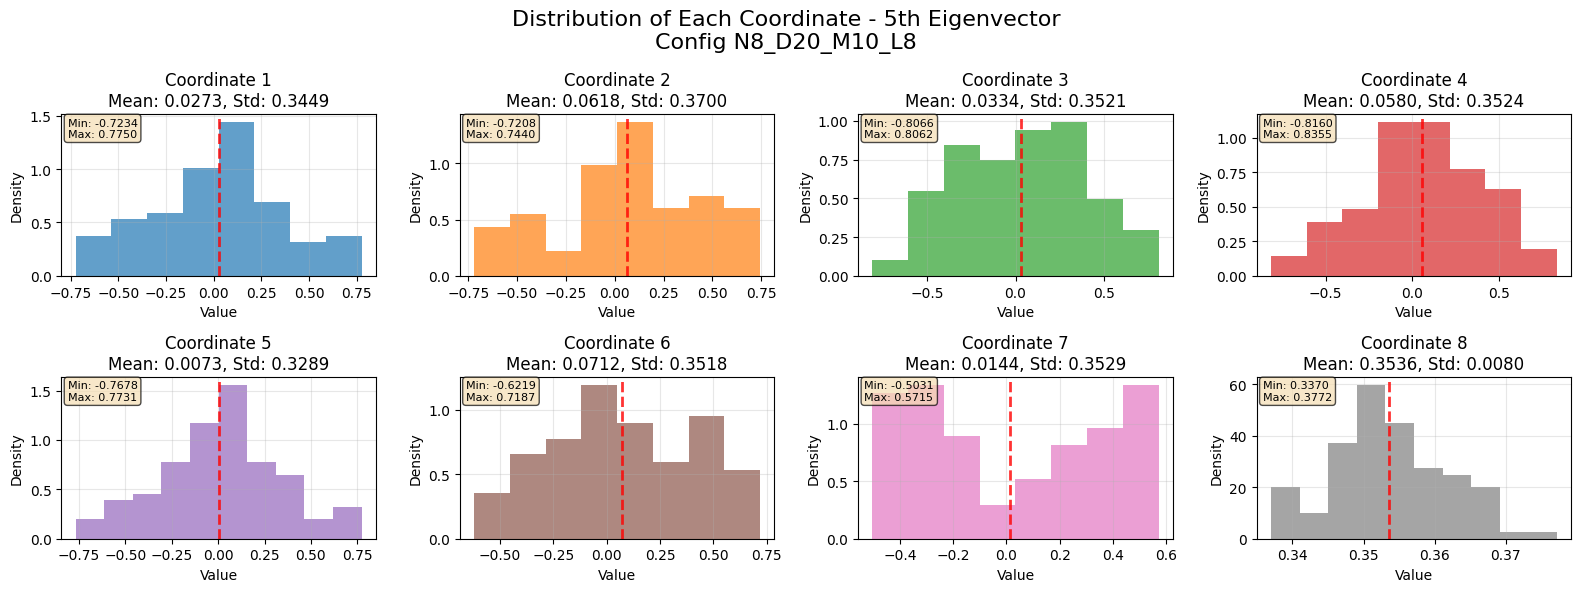

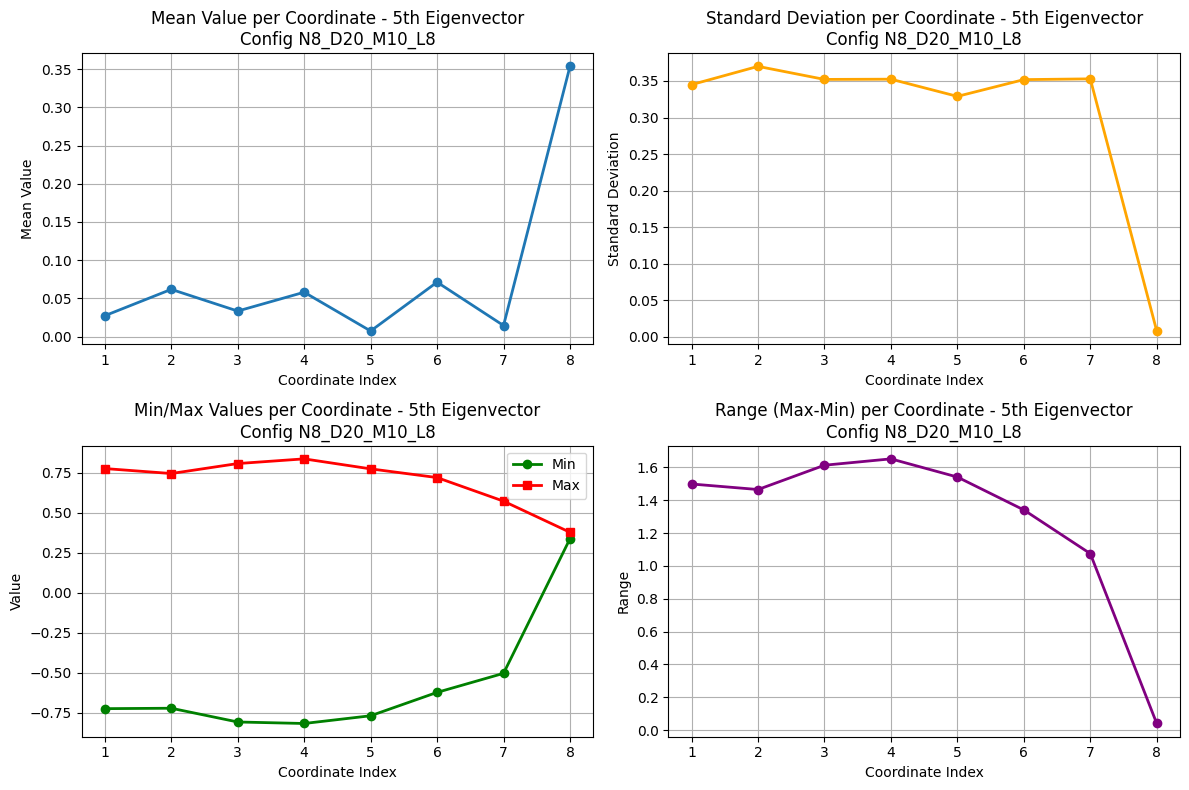

Coordinate analysis completed for 5th eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.078367
  Overall std of means: 0.106231
  Average std across coordinates: 0.307635


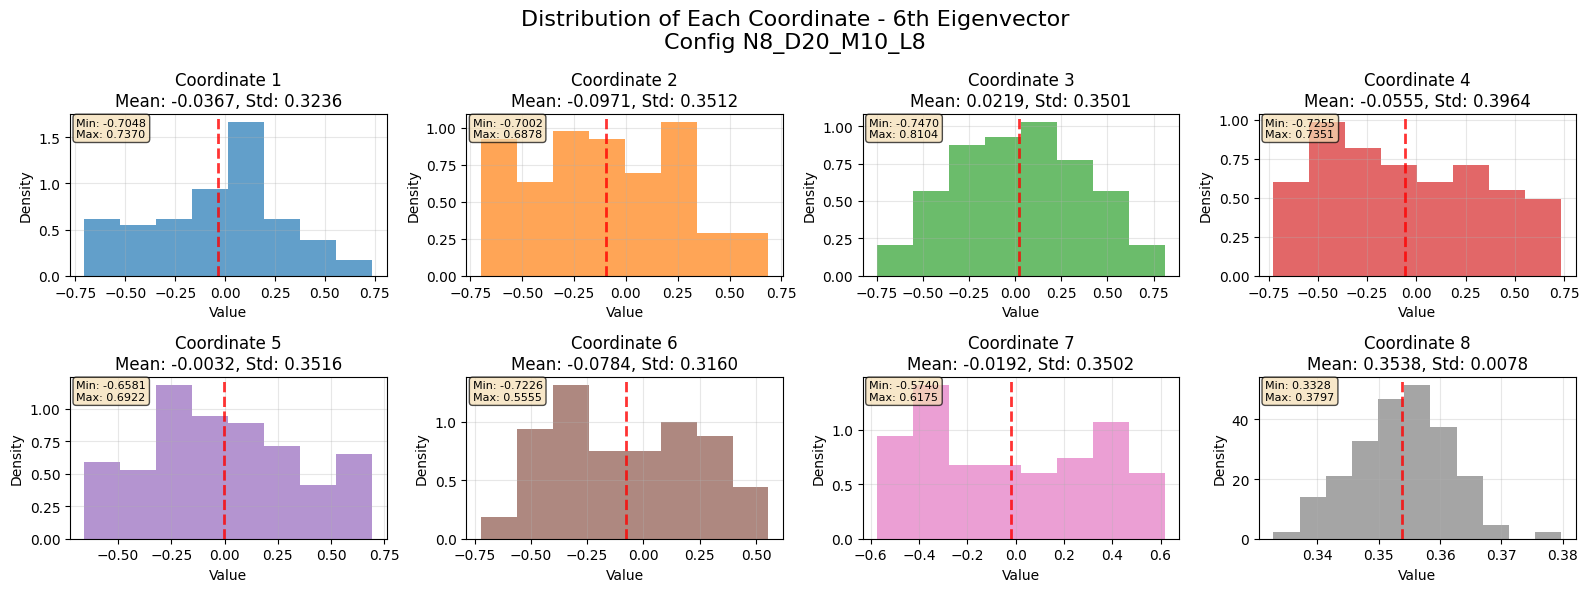

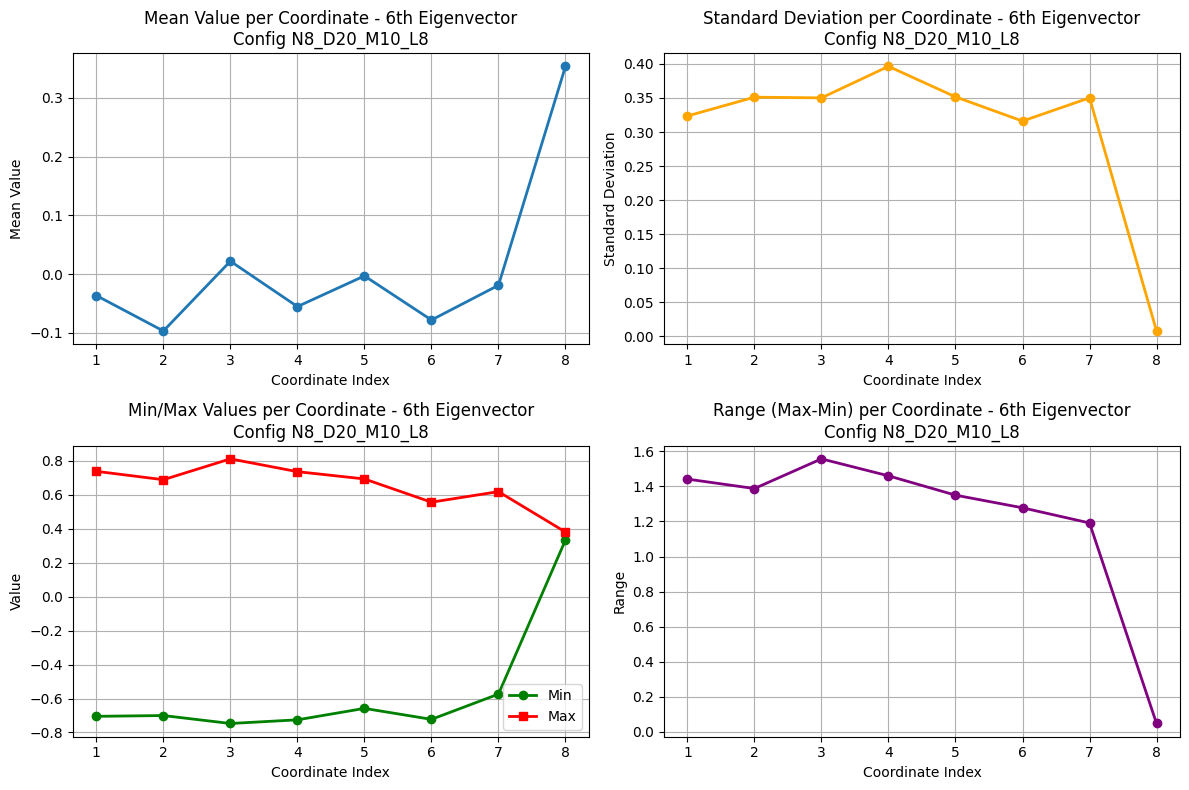

Coordinate analysis completed for 6th eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.010701
  Overall std of means: 0.134667
  Average std across coordinates: 0.305877


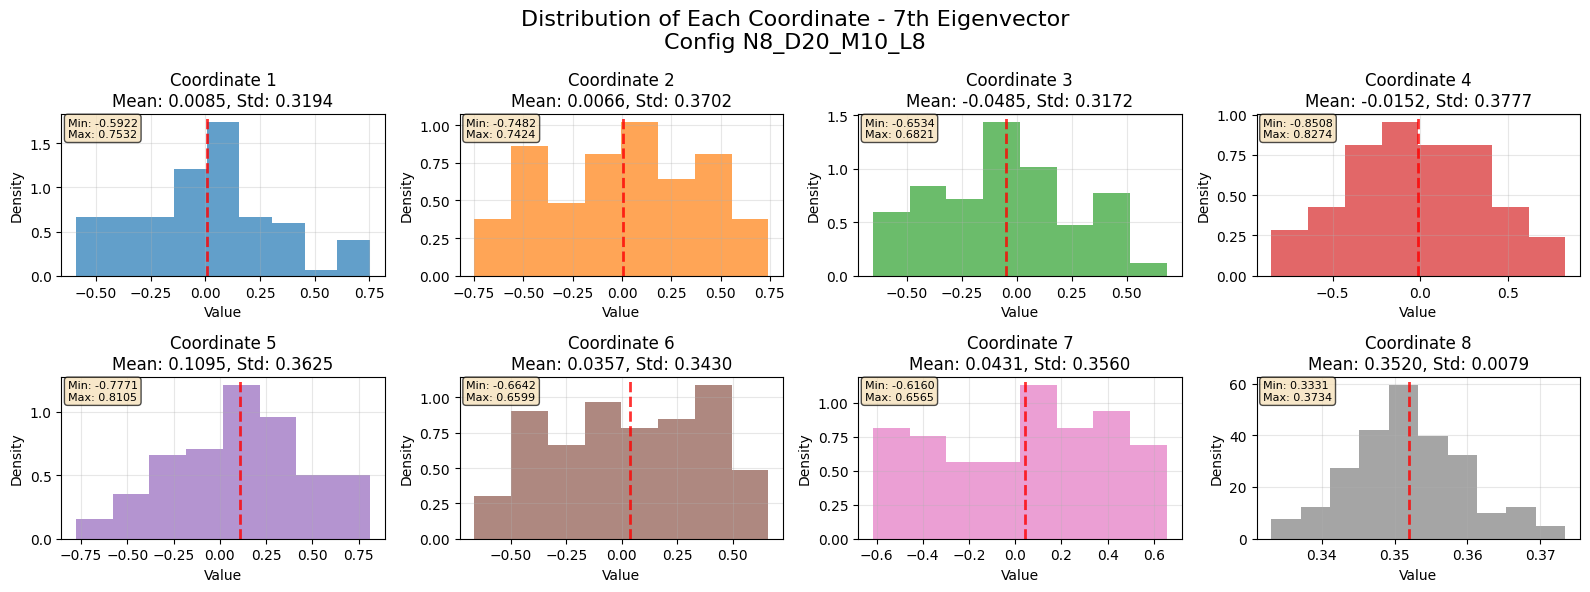

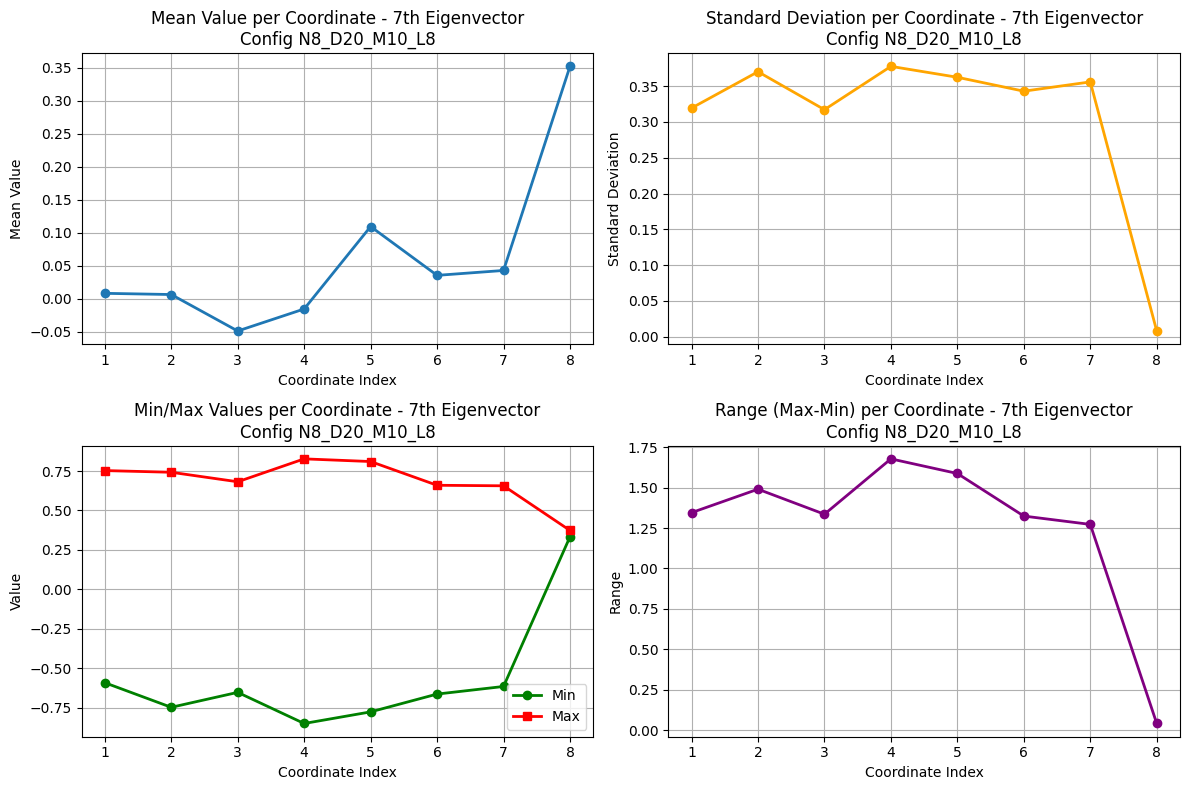

Coordinate analysis completed for 7th eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.061442
  Overall std of means: 0.118055
  Average std across coordinates: 0.306761


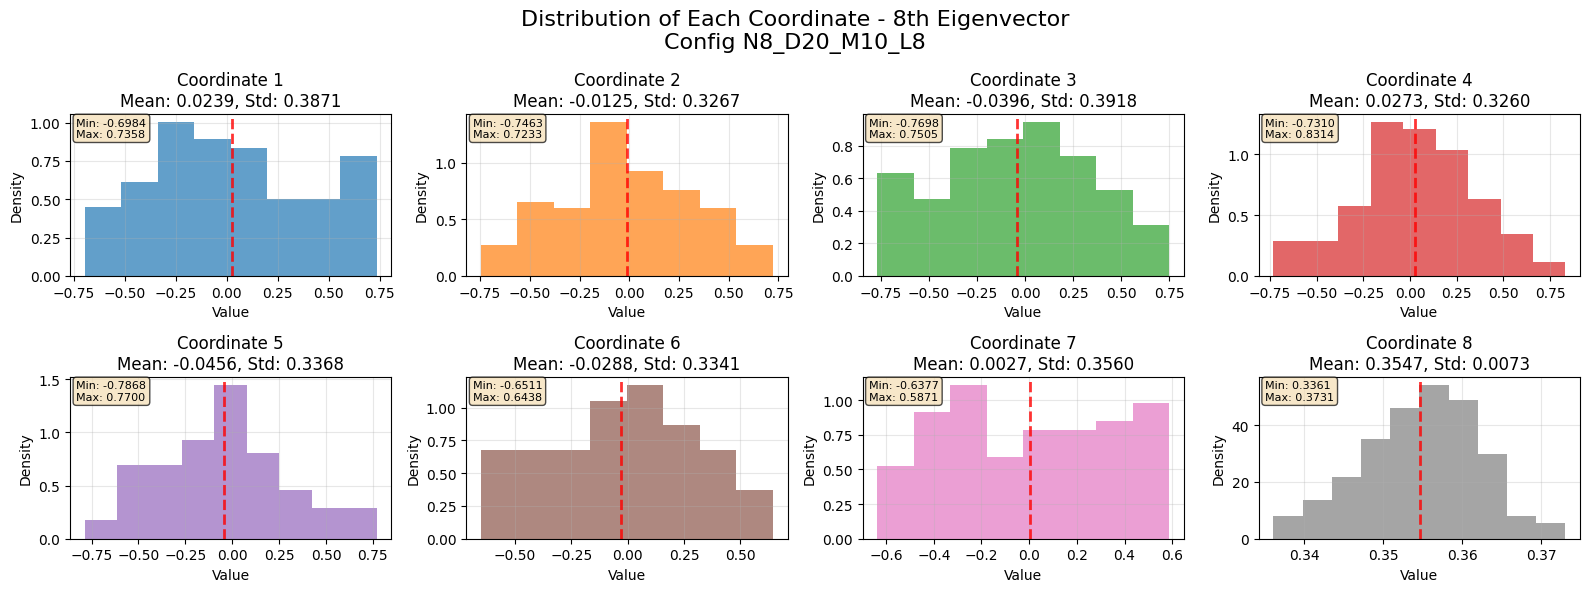

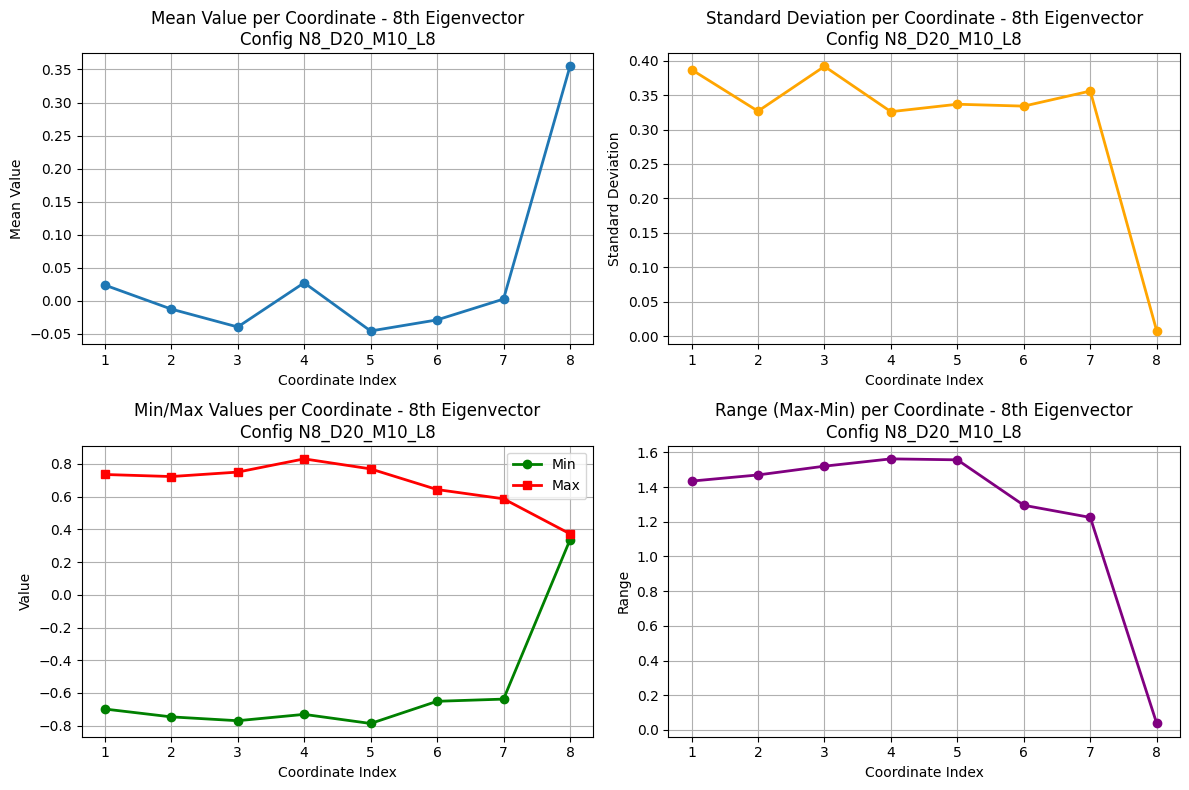

Processing eigenvectors for N8_D20_M10_L8: 100%|██████████| 8/8 [00:13<00:00,  1.63s/it]

Coordinate analysis completed for 8th eigenvector - N8_D20_M10_L8
  Dimension: 8
  Overall mean of means: 0.035252
  Overall std of means: 0.123399
  Average std across coordinates: 0.308235
Completed coordinate analysis for all 8 eigenvectors - N8_D20_M10_L8
Computing Gram matrix for all eigenvectors - N8_D20_M10_L8


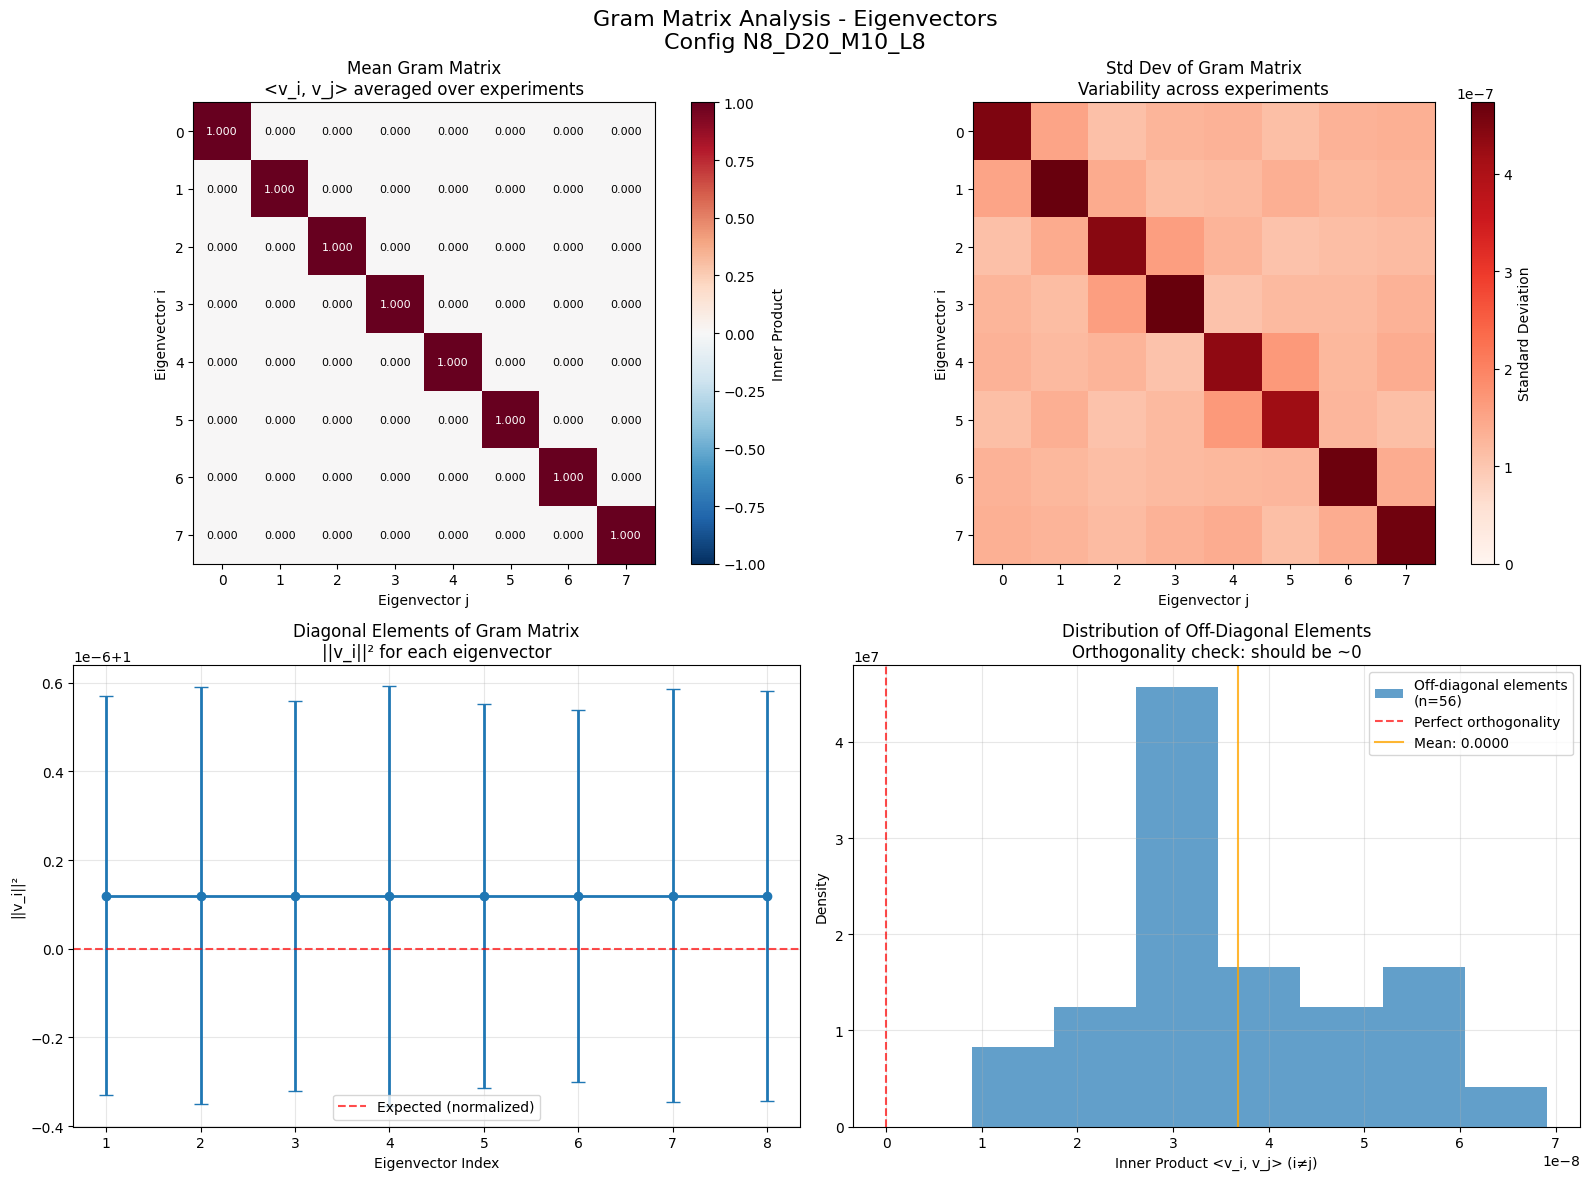

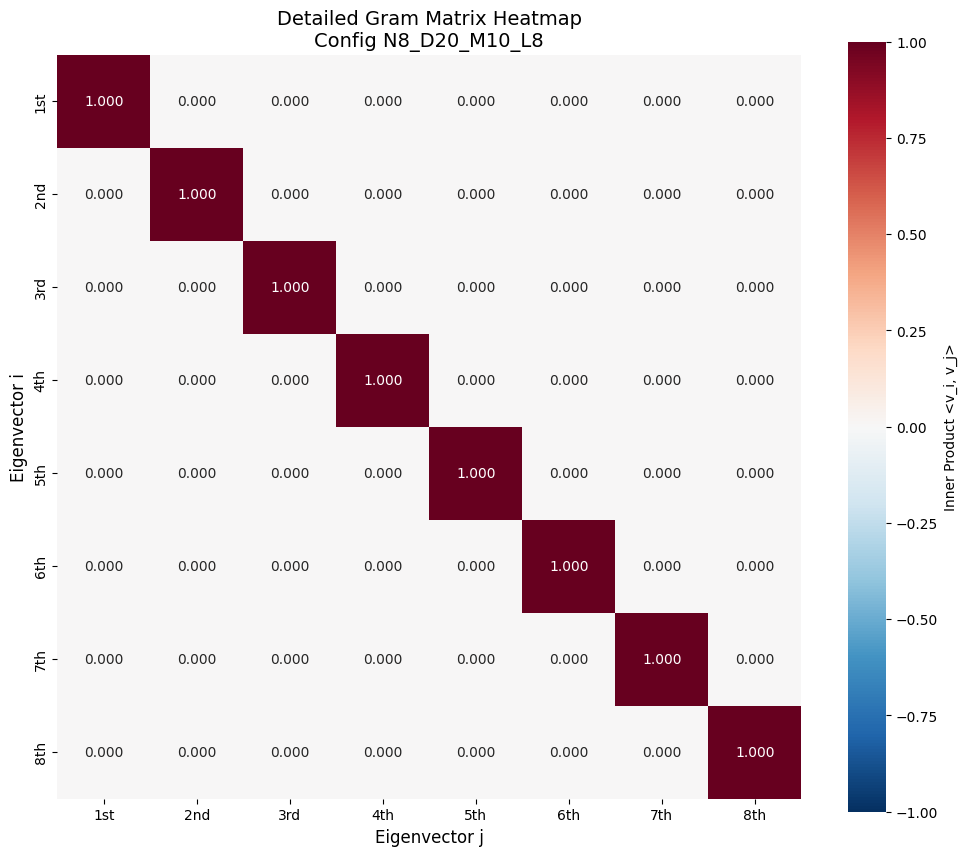

Processing experiment files: 100%|██████████| 1/1 [00:14<00:00, 14.35s/it]

Gram Matrix Statistics for N8_D20_M10_L8:
  Matrix shape: (8, 8)
  Diagonal mean: 1.000000 ± 0.000000
  Off-diagonal mean: 0.000000 ± 0.000000
  Max off-diagonal: 0.000000
  Orthogonality score (1 - max|<v_i,v_j>|): 1.000000
All eigenvectors coordinate analysis and Gram matrix computation complete!


In [ ]:
if __name__ == "__main__":
    # we process all files in the vectors directory
    files = [f for f in os.listdir(os.path.join(PATH_TO_DATA, "vectors")) if f.startswith('ntk_eigenvectors_')]
    
    # we sort files by N
    files = sorted(files, key=lambda x: get_config_from_filename(x)[0])
    
    files = files[:1]  # we process only the first file for testing
    print("Processing all experiment files for all eigenvectors coordinate analysis...")
    print("=" * 80)
    
    for file in tqdm(files, desc="Processing experiment files"):
        try:
            # we extract configuration from filename
            N, D_IN, M, L = get_config_from_filename(file)
            
            # we load eigenvectors data
            _, eigenvectors_data = load_experiment_data(N, D_IN, M, L)
            
            # we analyze coordinate distributions for all eigenvectors
            analyze_all_eigenvectors_coordinates(
                eigenvectors_data['eigenvectors'], N, D_IN, M, L, PATH_TO_PLOTS
            )
            
            # we compute and visualize the Gram matrix
            gram_stats = compute_and_plot_gram_matrix(
                eigenvectors_data['eigenvectors'], N, D_IN, M, L, PATH_TO_PLOTS
            )
            
        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    print("All eigenvectors coordinate analysis and Gram matrix computation complete!")